# Week4_ex3_to_4_analysis - Two Straight Wires: Parallel Force and the Region Wall Effect

![Week4_ex3 result](Images/Week4_ex3_result_image.png)

Two 500 mm copper wires (10 mm diameter, 12-sided), 100 A each, Magnetostatic. In Week4_ex3 they run parallel 50 mm apart; in Week4_ex4 one runs along x and the other along y, crossing 50 mm above it. Both notebooks get the Lorentz force on each wire, then switch one wire off at a time and sample |B| along the centerline of the other.

In both models every wire ends on a region face, so the wires behave as infinite lines. The only question is what the region's outer faces do. No boundary is assigned in either project, so all outer faces keep the Maxwell 3D default, where flux can't cross the boundary (B.n = 0). Inside a closed box that acts like mirror currents of opposite sign behind each wall. The infinite-wire formulas are the baseline, and the walled version is solved here as a 2D problem (sine series across the box) wherever the walls are close enough to matter.

This is a short check, not a hypothesis-driven one. The FEM values were already known when the comparison was set up, so nothing below is a blind prediction.

$$B=\frac{\mu_0 I}{2\pi\rho},\qquad \frac{F}{L}=\frac{\mu_0 I_1 I_2}{2\pi d}\quad\text{(parallel)},\qquad \mathbf{F}_{net}=0\quad\text{(perpendicular, by symmetry)}$$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Week4_ex3 results exported by the original notebook
b1_ex3 = pd.read_csv("Week4_ex3_B1.csv").iloc[:, 1].values      # wire 1 on, sampled along wire 2 [uT]
b2_ex3 = pd.read_csv("Week4_ex3_B2.csv").iloc[:, 1].values      # wire 2 on, sampled along wire 1 [uT]
force_ex3 = pd.read_csv("Week4_ex3_force_table.csv")

# 2. Model constants and the infinite-wire baseline
mu0 = 4e-7 * np.pi
I = 100.0
L = 0.5
d = 0.05
B_free = mu0 * I / (2 * np.pi * d)
F_free = mu0 * I**2 * L / (2 * np.pi * d)

In [3]:
# 3. |B| of an infinite line current inside a box whose walls force B.n = 0 (A = 0 on the walls), 2D cross-section.
#    Sine series along u, closed form along v -- v must carry the source/field separation, otherwise the series
#    only converges by oscillation.
def walled_B(u, v, src, ulim, vlim, kmax=20000):
    u0, v0 = src
    ulo, uhi = ulim
    vlo, vhi = vlim
    Lu, Lv = uhi - ulo, vhi - vlo
    k = np.arange(1, kmax) * np.pi / Lu

    def A(u, v):
        vl, vg = sorted((v - vlo, v0 - vlo))
        t = np.exp(-k * (vg - vl)) * (1 - np.exp(-2 * k * vl)) * (1 - np.exp(-2 * k * (Lv - vg))) / (1 - np.exp(-2 * k * Lv)) / 2
        return mu0 * I * np.sum(2 / Lu * np.sin(k * (u - ulo)) * np.sin(k * (u0 - ulo)) * t / k)

    h = 2e-5
    Bu = (A(u, v + h) - A(u, v - h)) / (2 * h)
    Bv = -(A(u + h, v) - A(u - h, v)) / (2 * h)
    return np.hypot(Bu, Bv)

# 4. Week4_ex3 walls: region padding is 800% in y and 6000% in z of the model bounding box (y +-30 mm, z +-5 mm)
ylim_ex3 = (-0.030 - 0.48, 0.030 + 0.48)
zlim_ex3 = (-0.005 - 0.60, 0.005 + 0.60)
B_walls_ex3 = walled_B(0.0, -0.025, (0.0, 0.025), zlim_ex3, ylim_ex3)
F_walls_ex3 = F_free * B_walls_ex3 / B_free

Fy1 = force_ex3["force_line1.Force_y [newton]"][0]
Fy2 = force_ex3["force_line2.Force_y [newton]"][0]
Fz1 = force_ex3["force_line1.Force_z [newton]"][0]
Fz2 = force_ex3["force_line2.Force_z [newton]"][0]

pd.DataFrame({
    "quantity": ["mean |B| along wire 2 (B_1) [uT]", "mean |B| along wire 1 (B_2) [uT]", "Force_y on wire 1 [mN]", "Force_y on wire 2 [mN]"],
    "FEM": [b1_ex3.mean(), b2_ex3.mean(), Fy1 * 1e3, Fy2 * 1e3],
    "infinite wire": [B_free * 1e6, B_free * 1e6, F_free * 1e3, -F_free * 1e3],
    "FEM vs infinite [%]": [(b1_ex3.mean() / (B_free * 1e6) - 1) * 100, (b2_ex3.mean() / (B_free * 1e6) - 1) * 100,
                            (Fy1 / F_free - 1) * 100, (-Fy2 / F_free - 1) * 100],
    "with walls": [B_walls_ex3 * 1e6, B_walls_ex3 * 1e6, F_walls_ex3 * 1e3, -F_walls_ex3 * 1e3],
    "FEM vs walls [%]": [(b1_ex3.mean() / (B_walls_ex3 * 1e6) - 1) * 100, (b2_ex3.mean() / (B_walls_ex3 * 1e6) - 1) * 100,
                         (Fy1 / F_walls_ex3 - 1) * 100, (-Fy2 / F_walls_ex3 - 1) * 100],
    "residual Force_z / Force_y [%]": [np.nan, np.nan, Fz1 / Fy1 * 100, Fz2 / Fy2 * 100],
}).round(3)

,quantity,FEM,infinite wire,FEM vs infinite [%],with walls,FEM vs walls [%],residual Force_z / Force_y [%]
0,mean |B| along wire 2 (B_1) [uT],399.319,400.0,-0.170,398.743,0.145,NaN
1,mean |B| along wire 1 (B_2) [uT],399.084,400.0,-0.229,398.743,0.086,NaN
2,Force_y on wire 1 [mN],20.097,20.0,0.484,19.937,0.801,1.605
3,Force_y on wire 2 [mN],-20.039,-20.0,0.194,-19.937,0.510,-0.162


![Week4_ex3 B along the wires](Images/Week4_ex3_B_field_vs_position.png)

The plot from the original notebook shows both B_1 and B_2 sitting flat at about 400 uT along the full 500 mm, which is the infinite-wire behavior the region setup was meant to give. With the y-axis spanning +-20%, it can't show the -0.2% offset or the roughly -1% dip both curves share near the middle (around 250 mm), so those are read from the table instead.

The walls here are about 0.5 m from the wires, and they pull the field down by 0.31%. The FEM mean sits within 0.1% of that. The force agrees with the free-space parallel-wire formula to +0.2~0.5% (+0.5~0.8% against the walled value), and the two wires attract, as they should with currents in the same direction. The leftover Force_z on wire 1 is 1.6% of Force_y, which is bigger than that mismatch, so both are treated as mesh noise in the force extraction rather than anything physical.

## Week4_ex4 - Perpendicular wires, and field lines that end on the region walls

![Week4_ex4 result](../Week4_ex4/Images/Week4_ex4_result_image.png)

Same wires, current and spacing as ex3, but line_1 runs along x at z = 0 and line_2 along y at z = 50 mm. The setup also differs in ways that matter. The region is set by absolute position to x, y in [-250, 250] mm and z in [-500, 550] mm, so it's only as wide as the wires are long. Two dummy boxes add mesh control, and MaxLength was relaxed to 125 mm on the wires and outer dummy (25 mm on the inner one) to stay under the Student mesh cap.

Because each wire's field is sampled along the other wire, every field line ends right on a pair of region walls. That's where those walls should matter most.

In [4]:
# 5. Week4_ex4 results exported by the original notebook
b1_ex4 = pd.read_csv("../Week4_ex4/Week4_ex4_B1.csv").iloc[:, 1].values   # line_1 on, sampled along line_2 [uT]
b2_ex4 = pd.read_csv("../Week4_ex4/Week4_ex4_B2.csv").iloc[:, 1].values   # line_2 on, sampled along line_1 [uT]
force_ex4 = pd.read_csv("../Week4_ex4/Week4_ex4_force_table.csv")

# 6. Net force should vanish by symmetry; scale it against the force each half of a wire carries (infinite wires)
F_half = mu0 * I**2 / (2 * np.pi) * 0.5 * np.log(1 + (L / 2)**2 / d**2)

comps = ["force_line1.Force_x", "force_line1.Force_y", "force_line1.Force_z",
         "force_line2.Force_x", "force_line2.Force_y", "force_line2.Force_z"]
vals = np.array([force_ex4[f"{c} [newton]"][0] for c in comps])
pd.DataFrame({
    "component": comps,
    "FEM [mN]": vals * 1e3,
    "vs force on half a wire [%]": vals / F_half * 100,
    "vs ex3 parallel force [%]": vals / F_free * 100,
}).round(3)

,component,FEM [mN],vs force on half a wire [%],vs ex3 parallel force [%]
0,force_line1.Force_x,0.000,0.000,0.000
1,force_line1.Force_y,-0.226,-6.935,-1.130
2,force_line1.Force_z,-0.168,-5.161,-0.841
3,force_line2.Force_x,-0.560,-17.189,-2.800
4,force_line2.Force_y,-0.000,-0.000,-0.000
5,force_line2.Force_z,-0.352,-10.789,-1.758


![Week4_ex4 B along the wires](../Week4_ex4/Images/Week4_ex4_B_field_vs_position.png)

The original plot shows the expected peak of about 400 uT where the wires cross. It has no theory curve, though, so it hides the odd part: at the ends of each line the FEM gives about 118 uT, while an infinite wire 255 mm away should only give 78 uT. That's +50% at the ends.

The ends of each field line sit exactly on two region walls (for B_1, the y = +-250 mm walls; for B_2, the x = +-250 mm walls). With B.n = 0 there, the wall reflects the wire as a mirror current. Near the wall the field's normal part is cancelled and the tangential part is doubled, which raises |B|. The walled model below uses the actual region box for each cross-section.

In [5]:
# 7. Walled 2D model along each sampled line. B_1: line_1 (x-axis) seen along line_2 -> cross-section y-z,
#    source at (0, 0), field at (y, 50 mm). B_2: line_2 (y-direction, z = 50 mm) seen along line_1 -> cross-section x-z,
#    source at (0, 50 mm), field at (x, 0). Region walls from the absolute-position padding.
s = np.arange(0, 501) * 1e-3                   # Distance along the sampled line [m]
u = np.clip(s - 0.25, -0.25 + 1e-5, 0.25 - 1e-5)
side = (-0.25, 0.25)
zlim_ex4 = (-0.50, 0.55)

B1_walls = np.array([walled_B(ui, 0.05, (0.0, 0.0), side, zlim_ex4) for ui in u]) * 1e6
B2_walls = np.array([walled_B(ui, 0.0, (0.0, 0.05), side, zlim_ex4) for ui in u]) * 1e6
B_inf = mu0 * I / (2 * np.pi * np.hypot(s - 0.25, d)) * 1e6

# 8. Point-by-point comparison at a few positions
idx = [0, 50, 100, 150, 200, 240, 250, 260, 300, 400, 500]
pd.DataFrame({
    "position [mm]": idx,
    "infinite wire [uT]": B_inf[idx],
    "walled, B_1 [uT]": B1_walls[idx],
    "FEM B_1 [uT]": b1_ex4[idx],
    "walled, B_2 [uT]": B2_walls[idx],
    "FEM B_2 [uT]": b2_ex4[idx],
}).round(1)

,position [mm],infinite wire [uT],"walled, B_1 [uT]",FEM B_1 [uT],"walled, B_2 [uT]",FEM B_2 [uT]
0,0,78.4,119.0,117.0,119.0,118.3
1,50,97.0,124.6,124.2,124.6,125.9
2,100,126.5,143.9,144.6,143.9,140.6
3,150,178.9,187.5,186.1,187.5,192.5
4,200,282.8,282.6,278.8,282.6,276.0
5,240,392.2,386.1,382.1,386.1,381.9
6,250,400.0,393.5,399.2,393.5,400.3
7,260,392.2,386.1,385.2,386.1,384.6
8,300,282.8,282.6,279.8,282.6,282.7
9,400,126.5,143.9,142.8,143.9,142.4


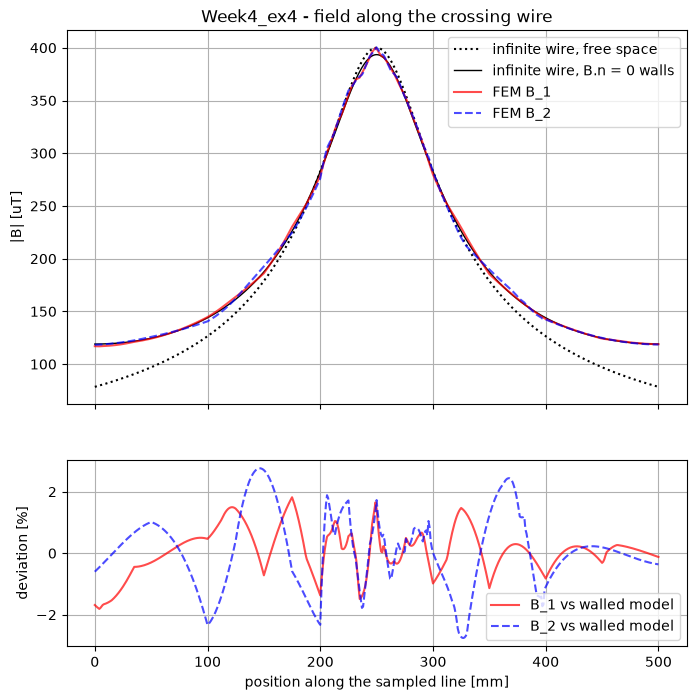

,line,end value FEM / infinite wire [%],end value FEM / walled [%],max |dev| outside +-20 mm of the crossing [%],max |dev| within +-20 mm of the crossing [%]
0,B_1,49.17,-1.69,1.82,1.65
1,B_2,50.81,-0.60,2.76,1.78


In [6]:
# 9. Deviation from the walled model along both lines, plus the summary numbers
dev1 = (b1_ex4 / B1_walls - 1) * 100
dev2 = (b2_ex4 / B2_walls - 1) * 100
far = (np.abs(s - 0.25) >= 0.02)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(s * 1e3, B_inf, "k:", label="infinite wire, free space")
ax1.plot(s * 1e3, B1_walls, "k-", linewidth=1, label="infinite wire, B.n = 0 walls")
ax1.plot(s * 1e3, b1_ex4, "r-", alpha=0.7, label="FEM B_1")
ax1.plot(s * 1e3, b2_ex4, "b--", alpha=0.7, label="FEM B_2")
ax1.set_ylabel("|B| [uT]")
ax1.set_title("Week4_ex4 - field along the crossing wire")
ax1.grid(True)
ax1.legend()
ax2.plot(s * 1e3, dev1, "r-", alpha=0.7, label="B_1 vs walled model")
ax2.plot(s * 1e3, dev2, "b--", alpha=0.7, label="B_2 vs walled model")
ax2.set_xlabel("position along the sampled line [mm]")
ax2.set_ylabel("deviation [%]")
ax2.grid(True)
ax2.legend()
plt.savefig("Images/Week4_ex4_B_field_vs_wall_model.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "line": ["B_1", "B_2"],
    "end value FEM / infinite wire [%]": [(b1_ex4[0] / B_inf[0] - 1) * 100, (b2_ex4[0] / B_inf[0] - 1) * 100],
    "end value FEM / walled [%]": [dev1[0], dev2[0]],
    "max |dev| outside +-20 mm of the crossing [%]": [np.abs(dev1[far]).max(), np.abs(dev2[far]).max()],
    "max |dev| within +-20 mm of the crossing [%]": [np.abs(dev1[~far]).max(), np.abs(dev2[~far]).max()],
}).round(2)

## Conclusion

**Week4_ex3.** Parallel wires behave like textbook infinite lines. The region walls, about 0.5 m out, lower the field by 0.31%, and the FEM mean B sits within 0.1% of that walled value. The force matches mu0*I^2*L/(2*pi*d) to +0.2~0.5% (+0.5~0.8% with the walls) and is attractive, as it should be for currents in the same direction. The 1.6% stray Force_z on wire 1 and the roughly 1% dip both B curves share near the middle are of the same order, so I left them as mesh noise. No further analysis needed.

**Week4_ex4.** The net force on each wire should be zero by symmetry, and the FEM leaves 0.2~0.6 mN, which is 5~17% of the force each half-wire carries. With MaxLength at 125 mm (four elements along a wire), this is mesh noise rather than physics, but it is noticeably bigger than in ex3. The field result is the more interesting part. At the ends of each sampled line the FEM is about 50% above the infinite-wire value, and that is fully explained by the region walls. Those walls sit right where the field lines end, and with B.n = 0 they act as mirrors that double the tangential field. The walled 2D model reproduces the ends to within 1.7%, and the whole curve to within about 3%. What's left is a wiggle of +-3% on a scale of roughly 100 mm (lower plot), which looks like the 25~125 mm element size rather than a trend - it even runs through the crossing, where the FEM happens to land on the free-space 400 uT instead of the model's 393.5 uT. This is the same kind of effect as a field line touching a region boundary, but with the default B.n = 0 walls it pushes the field up instead of down. The infinite-wire curve is only the right reference when the sampled line stays well clear of the walls.